In [1]:
%pip install pyserial
%pip install numpy pandas matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import tkinter as tk
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
from datetime import datetime
import os 
import sys
import re
import signal


plt.style.use("dark_background")

Check connection with the port and set the serial function (rest of the code will only work once this is ran)

In [80]:
def serial_ports():
    """ Lists serial port names

        :raises EnvironmentError:
            On unsupported or unknown platforms
        :returns:
            A list of the serial ports available on the system
    """
    if sys.platform.startswith('win'):
        ports = ['COM%s' % (i + 1) for i in range(256)]
    elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
        # this excludes your current terminal "/dev/tty"
        ports = glob.glob('/dev/tty[A-Za-z]*')
    elif sys.platform.startswith('darwin'):
        ports = glob.glob('/dev/tty.*')
    else:
        raise EnvironmentError('Unsupported platform')

    result = []
    for port in ports:
        try:
            s = serial.Serial(port)
            s.close()
            result.append(port)
        except (OSError, serial.SerialException):
            pass
    return result

def findDevice(question="hello", answer="", flush=False, timeout=5):
    for port in serial_ports():
        with serial.Serial(port, baudrate=115200, timeout=timeout) as ser:
            time.sleep(2)  # let the board finish resetting after port open
            ser.reset_input_buffer()

            if flush:
                ser.flush()
                time.sleep(0.5)

            ser.write(question.encode())
            time.sleep(0.5)

            msg = ser.readline().decode(errors="replace")
            print(f"{port}: {msg!r}")
            if answer and answer in msg:
                print(f"Found device at: {port}, answer: {msg}")
                return port
    return None



def send_read_command(port, string, required_string=None, baudrate=115200, timeout=10):
    """
    Opens the serial port, sends a “hello” and then your command, and collects replies.
    Stops reading when either:
      • no more data arrives (an empty readline, i.e. per-read timeout fired), or
      • we see `required_string` in the response, if given, or
      • the overall `timeout` has elapsed.
    Returns the list of lines read so far.
    """
    lines = []
    start = time.monotonic()
    with serial.Serial(port, baudrate=baudrate, timeout=timeout) as ser:
        # hand-shake / mode set
        ser.setRTS(False)
        ser.flush()
        time.sleep(0.7)
        ser.write(b"hello\n")
        time.sleep(0.5)
        ser.write(f"{string}\n".encode())
        last_recv = time.monotonic()

        while True:
            # Check idle timeout
            now = time.monotonic()
            if now - last_recv >= timeout:
                print(f"No (additional) responses within user-set timeout: {timeout}s")
                return lines
            
            try:
                line = ser.readline().decode('utf-8', errors='replace').strip()
                # print(line)
                
                last_recv = time.monotonic() # Reset idle timer since we got data
            except Exception as e:
                print(f"Error reading line: {e!s}")
                break

            # if nothing arrived within per-read timeout, readline() returns b'' → line == ''
            if not line:
                print(f"No (additional) responses within user-set timeout: {timeout}s")
                return lines
                
            lines.append(line)

            # if we were waiting for a specific marker, stop when we see it
            if required_string and required_string in line:
                break
    return lines



In [91]:
PORT = findDevice(question="hello\r\n", answer="C12666MA,v1.0", timeout=5)
if not PORT:
    raise RuntimeError("Device not found on any port")# Replace with the appropriate serial port for your device      

PORT = ports[0]
ser = serial.Serial(PORT, baudrate=115200, timeout=5)
time.sleep(2)  # Wait for the serial connection to initialize
ser.reset_input_buffer()

ser.write(b"hello\n")
message = ser.readline()
print(message.decode().strip())
time.sleep(1)
ser.close()

COM10: 'C12666MA,v1.0\r\n'
Found device at: COM10, answer: C12666MA,v1.0

C12666MA,v1.0


In [109]:
def measure_spec(port):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        # ser.write(b"hello\r\n")
        # time.sleep(0.5)
        # ser.readline()  # discard handshake reply

        ser.write(b"spec,raw\n")
        time.sleep(10)
        spec_raw = ser.readline()
        return spec_raw.decode(errors="replace").strip()

def set_gain(gain, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        # ser.write(b"hello\r\n")
        # time.sleep(0.5)
        # ser.readline()  # discard handshake reply

        command = f"set_gain,{gain}\n"
        ser.write(command.encode())
        time.sleep(1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_integration(integration_time, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_integration,{integration_time}\n"
        ser.write(command.encode())
        time.sleep(1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_avg(average_count, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_avg,{average_count}\n"
        ser.write(command.encode())
        time.sleep(1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

In [117]:
print(measure_spec(PORT))

62,64,62,61,58,65,65,65,59,63,62,59,58,60,60,64,61,64,58,61,60,61,65,62,60,61,60,62,63,65,64,59,60,64,61,64,61,60,67,66,67,71,68,75,76,86,93,98,111,129,148,175,194,215,225,225,212,195,178,158,150,139,128,120,116,112,112,115,110,115,119,120,121,122,124,128,127,132,129,132,135,138,138,137,143,143,150,149,156,156,159,161,161,162,160,161,161,160,158,161,166,167,168,170,172,165,168,165,171,171,174,172,175,172,167,167,165,163,166,163,165,170,177,182,188,192,194,191,195,190,184,179,177,169,165,161,162,163,159,157,150,150,147,145,139,136,129,127,120,116,115,113,108,106,105,102,103,101,103,98,93,95,92,93,87,89,85,84,80,82,83,80,79,75,79,73,72,71,72,74,70,70,73,70,69,70,70,64,69,68,67,67,69,65,68,64,64,69,66,64,63,68,68,64,67,65,66,62,65,61,66,66,64,67,65,64,61,65,63,65,66,65,62,64,64,60,62,63,62,62,64,62,61,60,63,62,62,63,65,67,64,64,63,64,59,61,62,62,62,61,65,59,65,59,62,65


In [116]:
set_avg (1, port=PORT)


'{"n_avg":1}'

In [115]:
measurement = measure_spec(PORT)
print(measurement)

63,62,62,63,63,63,64,63,63,64,61,63,64,63,61,62,62,63,62,62,62,62,62,62,63,64,63,63,62,63,63,63,63,64,63,64,63,65,65,67,68,70,73,77,80,85,92,101,114,130,152,175,200,219,227,227,214,196,179,161,149,139,132,124,120,117,115,114,115,116,118,119,122,122,125,127,128,130,132,134,136,136,139,140,143,147,149,153,155,159,161,161,163,162,162,162,162,162,163,164,167,169,171,171,172,171,172,171,171,172,174,174,174,173,171,169,168,166,165,167,170,174,180,184,189,193,195,197,194,191,187,182,177,173,169,166,162,161,158,156,155,150,147,143,139,134,129,124,120,117,114,111,109,107,106,105,103,101,100,97,95,93,92,90,88,85,84,84,81,82,81,78,79,77,76,74,75,73,74,73,72,70,70,70,70,70,68,68,68,67,68,67,66,67,67,67,65,66,65,65,65,65,64,65,64,64,66,64,63,65,63,63,64,63,63,65,63,63,64,62,62,64,63,63,63,62,64,64,62,62,62,62,62,62,63,62,62,63,63,62,63,61,62,62,62,62,62,63,62,62,62,62,61,60,62,62


C:\Users\tolsm012\AppData\Local\Temp\ipykernel_19164\2113121528.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


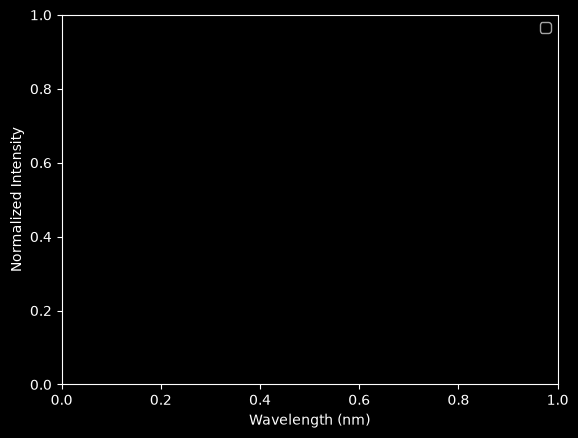

In [113]:
set_gain(0, port=PORT)
spec_raw = measure_spec(PORT)

with open("spec read TEST.csv","w") as f:
    meassurement = np.array(spec_raw.split(",")).astype(int)
    meas_norm = meassurement/np.max(meassurement) #normalize the measurement by dividing each value by the maximum value in the array.
    f.write(",".join([str(i) for i in meassurement]))

set_gain(1, port=PORT)
spec_raw = measure_spec(PORT)

with open("spec read TEST.csv","a") as f:
    meassurement = np.array(spec_raw.split(",")).astype(int)
    meas_norm = meassurement/np.max(meassurement) #normalize the measurement by dividing each value by the maximum value in the array.
    f.write(",".join([str(i) for i in meassurement]))
    
data = pd.read_csv("spec read TEST.csv")
for i in range(len(data)):
    y = data.iloc[i,1:]
    x = np.linspace(340,780,len(y))

    timestamp = data.iloc[i,0]
    plt.plot(x,y,label=f"{timestamp}")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity")  
plt.show()
